## Atividade 3 - Macroeconomia Avançada 1

### Aluno: José Kawan dos Santos Santana

In [4]:
import ipeadatapy as ip
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
# pip install python-bcb

In [6]:
import bcb
from bcb import sgs

#### Parte da documentação

[Python BCB documentação](https://wilsonfreitas.github.io/python-bcb/api.html)

In [8]:
ibc = bcb.sgs.get({'IBCbr': 24363}, start='2003-01-01'),            # IBC-Br mensal (índice)
comm = bcb.sgs.get({'commodities': 27574}, start='2003-01-01'),     # Índice de preços de commodities - Brasil (índice)
ipca = bcb.sgs.get({'IPCA': 433}, start='2003-01-01'),              # Variação percentual mensal do IPCA (variação % mensal)
selic = bcb.sgs.get({'Selic': 4390}, start='2003-01-01'),           # Taxa de juros - Selic acumulada no mês - (variação % mensal)
cambio = bcb.sgs.get({'Cambio': 3696}, start='2003-01-01'),         # Taxa de câmbio - Livre - Dólar americano (venda) - Fim de período - mensal (nível)

print(cambio)     

(            Cambio
Date              
2003-01-01  3.5258
2003-02-01  3.5632
2003-03-01  3.3531
2003-04-01  2.8898
2003-05-01  2.9656
...            ...
2024-11-01  6.0535
2024-12-01  6.1923
2025-01-01  5.8301
2025-02-01  5.8488
2025-03-01  5.7422

[267 rows x 1 columns],)


Eu coloquei o início das variáveis para janeiro de 2003 porque os dados do IBC-Br estão disponíveis a partir dessa data.

In [10]:
ibc = ibc[0]                     # pegando só a coluna de dados
comm = comm[0]
ipca = ipca[0]
selic = selic[0]
cambio = cambio[0]

# Transformar em DataFrames
ibc = pd.DataFrame(ibc)
comm = pd.DataFrame(comm)
ipca = pd.DataFrame(ipca)
selic = pd.DataFrame(selic)
cambio = pd.DataFrame(cambio)

# Ajustar índices para período mensal (caso o índice seja datetime)
ibc.index = pd.to_datetime(ibc.index).to_period('M')
comm.index = pd.to_datetime(comm.index).to_period('M')
ipca.index = pd.to_datetime(ipca.index).to_period('M')
selic.index = pd.to_datetime(selic.index).to_period('M')
cambio.index = pd.to_datetime(cambio.index).to_period('M')

In [11]:
display(cambio)

,Cambio
Date,
2003-01,3.5258
2003-02,3.5632
2003-03,3.3531
2003-04,2.8898
2003-05,2.9656
...,...
2024-11,6.0535
2024-12,6.1923
2025-01,5.8301


In [12]:
# Unir os três DataFrames pelo índice (join com interseção de datas)
df = pd.concat([ibc, comm, ipca, selic, cambio], axis=1).dropna()

# Visualizar o resultado
print(df.head())

            IBCbr  commodities  IPCA  Selic  Cambio
Date                                               
2003-01  67.44572       101.45  2.25   1.97  3.5258
2003-02  69.20861       109.05  1.57   1.83  3.5632
2003-03  72.53661       100.18  1.23   1.78  3.3531
2003-04  71.67673        90.84  0.97   1.87  2.8898
2003-05  70.35122        87.33  0.61   1.97  2.9656


Calcule uma medida de taxa de juros real utilizando o IPCA como deflator.

In [14]:
# criando uma medida de juros real com o IPCA como deflator

df['juros_real'] = df['Selic'] - df['IPCA']

print(df[['Selic', 'IPCA', 'juros_real']].head())

         Selic  IPCA  juros_real
Date                            
2003-01   1.97  2.25       -0.28
2003-02   1.83  1.57        0.26
2003-03   1.78  1.23        0.55
2003-04   1.87  0.97        0.90
2003-05   1.97  0.61        1.36


In [15]:
df2 = df[['IBCbr', 'commodities', 'IPCA', 'juros_real', 'Cambio']]

print(df2)

             IBCbr  commodities  IPCA  juros_real  Cambio
Date                                                     
2003-01   67.44572       101.45  2.25       -0.28  3.5258
2003-02   69.20861       109.05  1.57        0.26  3.5632
2003-03   72.53661       100.18  1.23        0.55  3.3531
2003-04   71.67673        90.84  0.97        0.90  2.8898
2003-05   70.35122        87.33  0.61        1.36  2.9656
...            ...          ...   ...         ...     ...
2024-10  109.49845       430.22  0.56        0.37  5.7779
2024-11  105.76017       447.00  0.39        0.40  6.0535
2024-12  104.44111       477.11  0.52        0.41  6.1923
2025-01  103.05176       482.57  0.16        0.85  5.8301
2025-02  106.61259       461.10  1.31       -0.32  5.8488

[266 rows x 5 columns]


#### A. Plote das séries

In [17]:
df.index = df.index.to_timestamp()

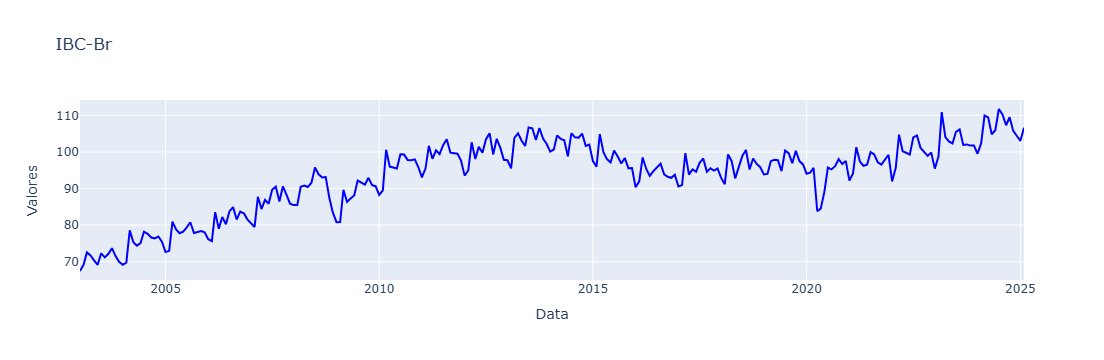

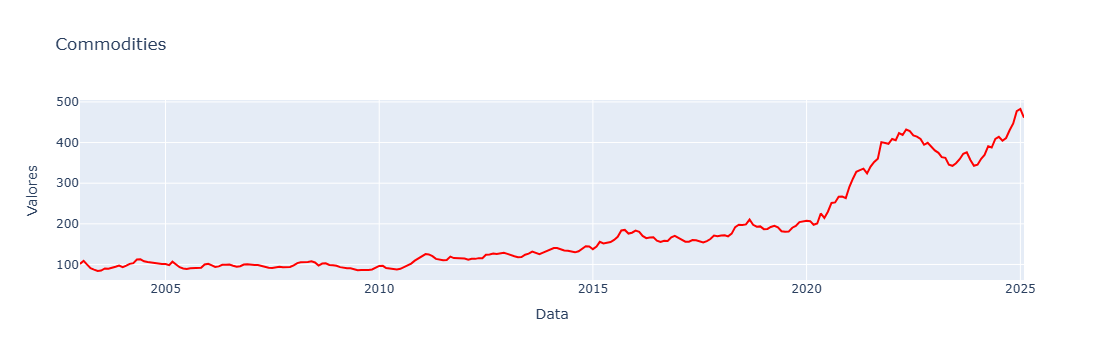

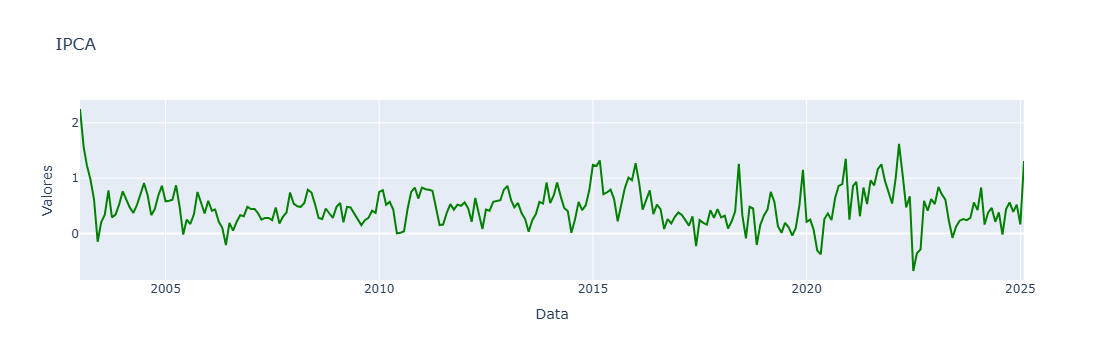

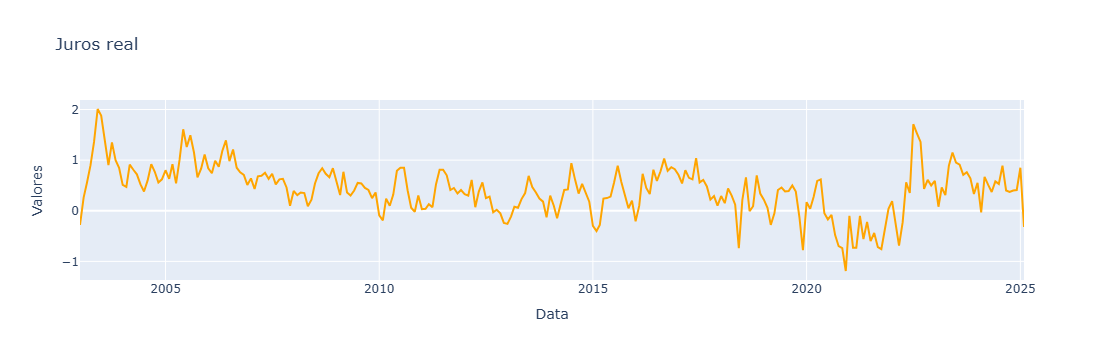

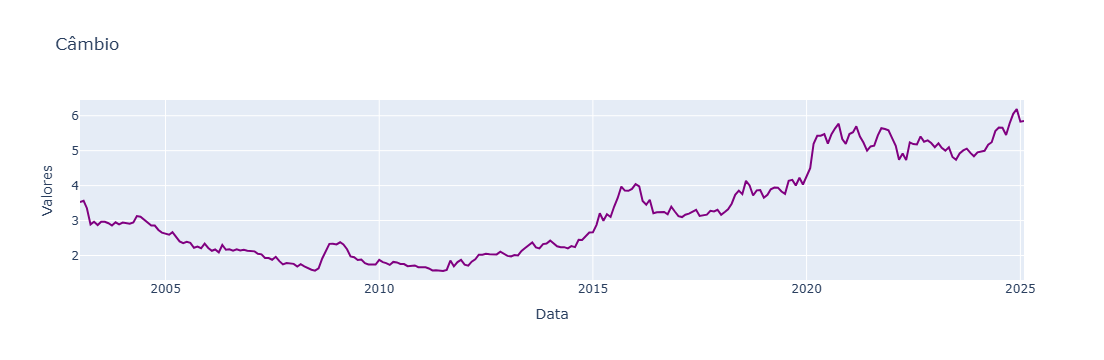

In [18]:
import plotly.graph_objects as go

# df.index = df.index.to_timestamp()

# Função para criar o gráfico de cada variável
def create_plot(x, y, title, yaxis_title, color):
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=x, y=y, mode='lines', name=title, line=dict(color=color)))
    fig.update_layout(
        title=title,
        xaxis_title='Data',
        yaxis_title=yaxis_title,
        hovermode='x unified'
    )
    fig.show()

# Criando os gráficos individuais
create_plot(df.index, df['IBCbr'], 'IBC-Br', 'Valores', 'blue')
create_plot(df.index, df['commodities'], 'Commodities', 'Valores', 'red')
create_plot(df.index, df['IPCA'], 'IPCA', 'Valores', 'green')
create_plot(df.index, df['juros_real'], 'Juros real', 'Valores', 'orange')
create_plot(df.index, df['Cambio'], 'Câmbio', 'Valores', 'purple')

In [19]:
##### Verificando estacionaridade das 5 séries

from statsmodels.tsa.stattools import adfuller

# Verificar estacionariedade (opcional)
for col in df2.columns:
    result = adfuller(df2[col].dropna())
    print(f"{col}: p-value = {result[1]:.4f}")

IBCbr: p-value = 0.3590
commodities: p-value = 0.9941
IPCA: p-value = 0.0000
juros_real: p-value = 0.0000
Cambio: p-value = 0.9687


- **H₀ (Hipótese Nula)**:
"A série tem uma raiz unitária (não é estacionária)."
Em outras palavras, há uma tendência estocástica (como um passeio aleatório) que torna a série dependente do tempo.
- **H₁ (Hipótese Alternativa)**:
"A série não tem raiz unitária (é estacionária)."
Isso significa que a série flutua em torno de uma média constante, com variância finita e sem tendência temporal

As séries do IPCA e dos juros reais são estacionárias. Vou estacionarizar as 3 outras séries e refazer o teste de estacionaridade.

In [21]:
# Diferenciação de primeira ordem
df2['IBCbr_diff'] = df2['IBCbr'].diff().dropna()
df2['commodities_diff'] = df2['commodities'].diff().dropna()
df2['Cambio_diff'] = df2['Cambio'].diff().dropna()

print(df2)

             IBCbr  commodities  IPCA  juros_real  Cambio  IBCbr_diff  \
Date                                                                    
2003-01   67.44572       101.45  2.25       -0.28  3.5258         NaN   
2003-02   69.20861       109.05  1.57        0.26  3.5632     1.76289   
2003-03   72.53661       100.18  1.23        0.55  3.3531     3.32800   
2003-04   71.67673        90.84  0.97        0.90  2.8898    -0.85988   
2003-05   70.35122        87.33  0.61        1.36  2.9656    -1.32551   
...            ...          ...   ...         ...     ...         ...   
2024-10  109.49845       430.22  0.56        0.37  5.7779     2.18617   
2024-11  105.76017       447.00  0.39        0.40  6.0535    -3.73828   
2024-12  104.44111       477.11  0.52        0.41  6.1923    -1.31906   
2025-01  103.05176       482.57  0.16        0.85  5.8301    -1.38935   
2025-02  106.61259       461.10  1.31       -0.32  5.8488     3.56083   

         commodities_diff  Cambio_diff  
Date     

In [22]:
# Passo 2: Remover linhas com NaN (resultado da diferenciação)
df3 = df2[['IBCbr_diff', 'commodities_diff', 'IPCA', 'juros_real', 'Cambio_diff']].dropna()

# Verificar o resultado
print(df3.head())

         IBCbr_diff  commodities_diff  IPCA  juros_real  Cambio_diff
Date                                                                
2003-02     1.76289              7.60  1.57        0.26       0.0374
2003-03     3.32800             -8.87  1.23        0.55      -0.2101
2003-04    -0.85988             -9.34  0.97        0.90      -0.4633
2003-05    -1.32551             -3.51  0.61        1.36       0.0758
2003-06    -1.20293             -3.37 -0.15        2.01      -0.0936


Os dados vão começar a partir de fevereiro de 2003 porque como eu diferenciei, perdi a primeira observação dessas variáveis diferenciadas.

In [24]:
#### verificar se as séries se tornarão estacionárias

from statsmodels.tsa.stattools import adfuller

for col in df3.columns:
    p_valor = adfuller(df3[col].dropna())[1]
    print(f"{col}: p-valor = {p_valor:.4f}")

IBCbr_diff: p-valor = 0.0010
commodities_diff: p-valor = 0.0026
IPCA: p-valor = 0.0000
juros_real: p-valor = 0.0488
Cambio_diff: p-valor = 0.0000


#### B. Escolha lags por AIC/SBC/HQ

In [26]:
from statsmodels.tsa.api import VAR

# Seleção do número ótimo de lags com base nos critérios de informação
model = VAR(df3)
lag_selection = model.select_order(maxlags=20)

# Exibindo os resultados dos critérios
print(lag_selection.summary())

# Pegando o número de lags sugerido por cada critério
aic_lag = lag_selection.aic
bic_lag = lag_selection.bic
hqic_lag = lag_selection.hqic

print(f"Lag escolhido pelo AIC: {aic_lag}")
print(f"Lag escolhido pelo BIC (SBC): {bic_lag}")
print(f"Lag escolhido pelo Hannan-Quinn: {hqic_lag}")

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -1.940      -1.868      0.1438      -1.911
1       -5.067      -4.638    0.006300      -4.895
2       -5.592     -4.806*    0.003727      -5.276
3       -5.672      -4.529    0.003444      -5.212
4       -5.805      -4.304    0.003020      -5.200
5       -5.998      -4.140    0.002494      -5.250
6       -6.293      -4.078    0.001862     -5.401*
7       -6.260      -3.687    0.001932      -5.224
8       -6.346      -3.417    0.001781      -5.167
9       -6.407      -3.121    0.001687      -5.084
10      -6.559      -2.915    0.001462      -5.091
11      -6.653      -2.651    0.001345      -5.041
12      -6.905      -2.546   0.001058*      -5.150
13      -6.838      -2.122    0.001148      -4.938
14      -6.853      -1.780    0.001151      -4.810
15      -6.855      -1.424    0.001172      -4.668
16      -6.840      -1.052    0

#### C. Estime o modelo VAR e realize os testes de diagnóstico/especificação do modelo como indicados em sala de aula.

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import acf

In [29]:
# Criar o modelo VAR
model = VAR(df3)

# Ajustar o modelo com p lags
results = model.fit(13)
print(results.summary())

  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 29, Apr, 2025
Time:                     20:02:53
--------------------------------------------------------------------
No. of Equations:         5.00000    BIC:                   -2.22297
Nobs:                     252.000    HQIC:                  -4.98510
Log likelihood:          -595.412    FPE:                 0.00113359
AIC:                     -6.84484    Det(Omega_mle):     0.000354260
--------------------------------------------------------------------
Results for equation IBCbr_diff
                          coefficient       std. error           t-stat            prob
---------------------------------------------------------------------------------------
const                        0.480562         0.644921            0.745           0.456
L1.IBCbr_diff               -0.141212         0.084261           -1.676           0.094
L1.commodities_diff        

##### Autocorrelação dos resíduos (Ljung-Box)

- **H₀ (Hipótese Nula)**:
Os resíduos não são autocorrelacionados (ou seja, seguem um processo de ruído branco).
(Não há padrões de correlação serial nos resíduos.)
- **H₁ (Hipótese Alternativa)**:
Os resíduos são autocorrelacionados (há dependência temporal nos resíduos).uos).

In [31]:
# Obter os resíduos
resid = results.resid

# Teste de Ljung-Box para autocorrelação
from statsmodels.stats.diagnostic import acorr_ljungbox

for col in resid.columns:
    lb_test = acorr_ljungbox(resid[col], lags=[12], return_df=True)
    print(f"Teste Ljung-Box para {col}:")
    print(lb_test)
    print("\n")

Teste Ljung-Box para IBCbr_diff:
      lb_stat  lb_pvalue
12  14.253314   0.284826


Teste Ljung-Box para commodities_diff:
     lb_stat  lb_pvalue
12  6.466123   0.890789


Teste Ljung-Box para IPCA:
     lb_stat  lb_pvalue
12  1.864792   0.999587


Teste Ljung-Box para juros_real:
     lb_stat  lb_pvalue
12  1.301865   0.999939


Teste Ljung-Box para Cambio_diff:
     lb_stat  lb_pvalue
12  3.643162   0.989049




Exemplo dos juros real: Isso significa que falhamos em rejeitar H₀, ou seja, não há evidência de autocorrelação nos resíduos da variável juros_real para as defasagens testadas (até lag 13).

##### Normalidade dos resíduos (D’Agostino-Pearson test)

- **H₀ (Hipótese Nula)**:
Os resíduos seguem uma distribuição normal (média zero, variância constante, simetria e curtose adequadas).
- **H₁ (Hipótese Alternativa)**:
Os resíduos não seguem uma distribuição normal (podem ser assimétricos, ter caudas pesadas ou outliers excessivos).os).

In [34]:
from scipy.stats import normaltest

for col in resid.columns:
    stat, p = normaltest(resid[col])
    print(f"Teste de normalidade para {col}: estatística={stat:.3f}, p-valor={p:.3f}")
    if p > 0.05:
        print("Resíduos parecem normais\n")
    else:
        print("Resíduos não parecem normais\n")

Teste de normalidade para IBCbr_diff: estatística=8.396, p-valor=0.015
Resíduos não parecem normais

Teste de normalidade para commodities_diff: estatística=8.864, p-valor=0.012
Resíduos não parecem normais

Teste de normalidade para IPCA: estatística=2.226, p-valor=0.329
Resíduos parecem normais

Teste de normalidade para juros_real: estatística=1.037, p-valor=0.595
Resíduos parecem normais

Teste de normalidade para Cambio_diff: estatística=12.709, p-valor=0.002
Resíduos não parecem normais



##### Teste de heterocedasticidade dos resíduos

- **H₀ (Hipótese Nula)**:
Não há heterocedasticidade condicional (os resíduos têm variância constante).
- **H₁ (Hipótese Alternativa)**:
Há heterocedasticidade condicional (a variância dos resíduos depende de valores passados).

In [36]:
from statsmodels.stats.diagnostic import het_arch

for col in resid.columns:
    arch_test = het_arch(resid[col])
    print(f"Teste ARCH para {col}:")
    print(f"Estatística LM: {arch_test[0]}, p-valor: {arch_test[1]}")
    if arch_test[1] > 0.05:
        print("Não há evidência de heterocedasticidade\n")
    else:
        print("Há evidência de heterocedasticidade\n")

Teste ARCH para IBCbr_diff:
Estatística LM: 2.3871260751263437, p-valor: 0.9924204670772117
Não há evidência de heterocedasticidade

Teste ARCH para commodities_diff:
Estatística LM: 10.413941920511615, p-valor: 0.40495738777261414
Não há evidência de heterocedasticidade

Teste ARCH para IPCA:
Estatística LM: 11.100902717285571, p-valor: 0.3497110027449318
Não há evidência de heterocedasticidade

Teste ARCH para juros_real:
Estatística LM: 12.025433458388216, p-valor: 0.28335794047844826
Não há evidência de heterocedasticidade

Teste ARCH para Cambio_diff:
Estatística LM: 12.51910691190708, p-valor: 0.25181479603476736
Não há evidência de heterocedasticidade



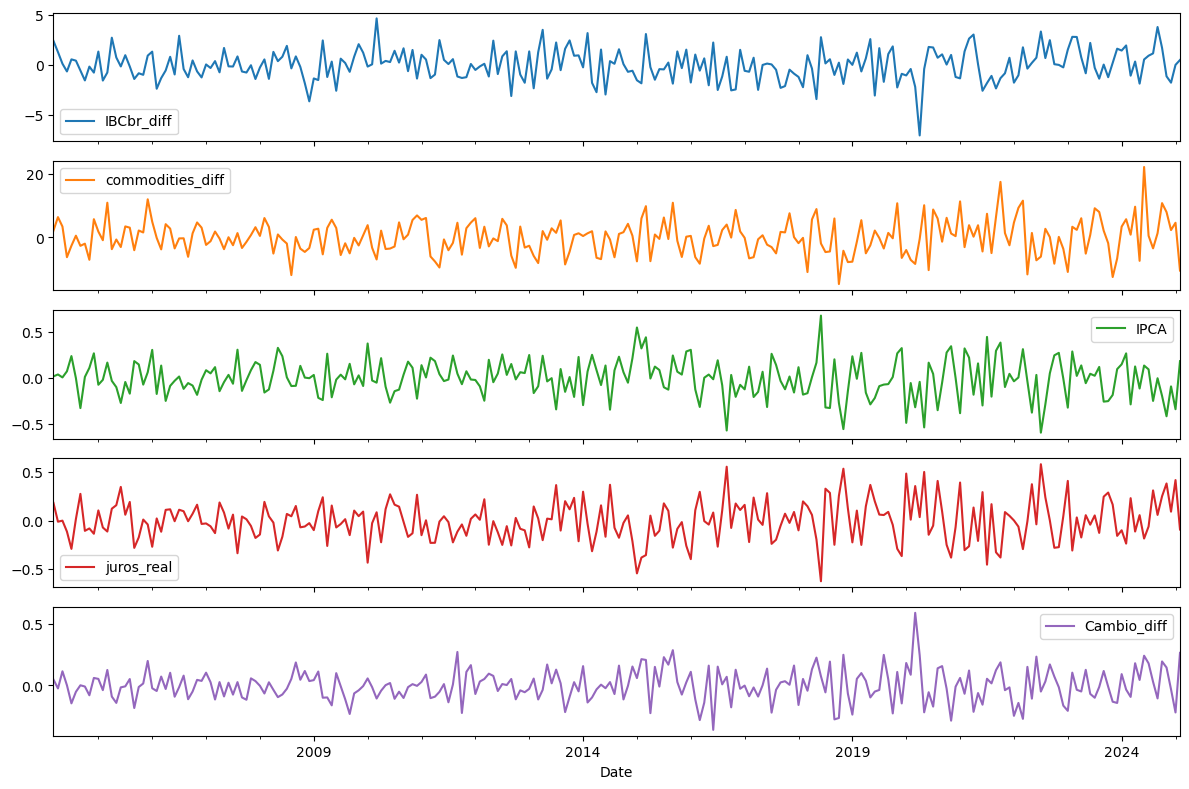

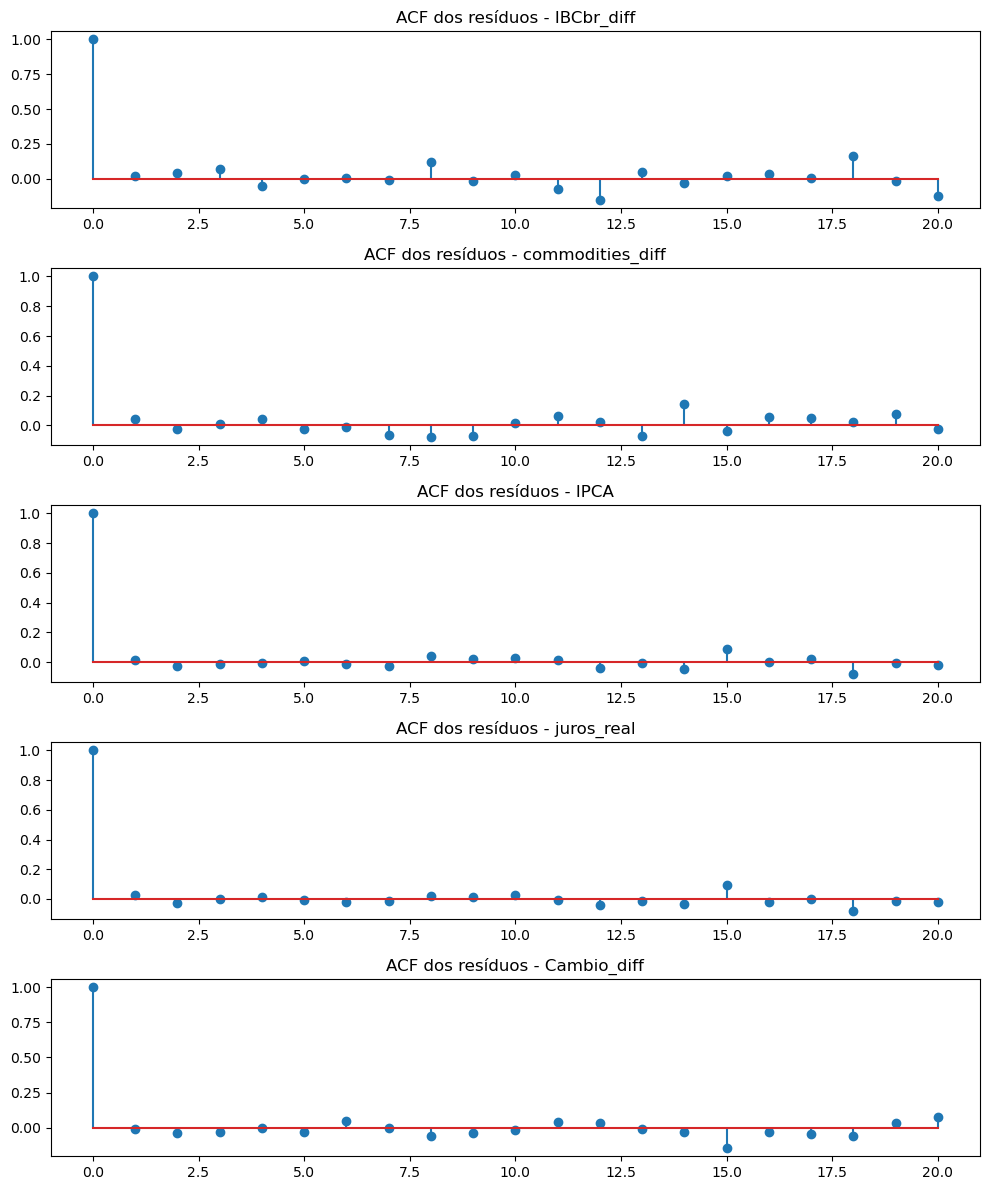

In [37]:
# Plotar resíduos
resid.plot(subplots=True, figsize=(12, 8))
plt.tight_layout()
plt.show()

# Plotar ACF dos resíduos
fig, axes = plt.subplots(nrows=len(resid.columns), ncols=1, figsize=(10, 12))
for i, col in enumerate(resid.columns):
    acf_vals = acf(resid[col], nlags=20)
    axes[i].stem(acf_vals)
    axes[i].set_title(f"ACF dos resíduos - {col}")
plt.tight_layout()
plt.show()

In [38]:
# Verificar as raízes do polinômio característico
roots = results.roots
print("Raízes do polinômio característico:")
print(roots)

# Verificar se o modelo é estável (todas as raízes devem estar fora do círculo unitário)
print("\nMódulo das raízes:")
print(np.abs(roots))
if np.all(np.abs(roots) > 1):
    print("O modelo VAR é estável")
else:
    print("O modelo VAR não é estável")

Raízes do polinômio característico:
[-4.45018077e+01-0.j          1.57610897e+00+2.23418572j
  1.57610897e+00-2.23418572j -1.75943714e+00-0.j
  3.43762558e-01+1.45916255j  3.43762558e-01-1.45916255j
  1.38874416e+00-0.j          9.73887432e-01-0.96425708j
  9.73887432e-01+0.96425708j -5.38482924e-01-1.20321606j
 -5.38482924e-01+1.20321606j -1.27441206e+00-0.j
  5.08690338e-01-1.15307379j  5.08690338e-01+1.15307379j
 -1.16648204e+00+0.45056617j -1.16648204e+00-0.45056617j
 -7.28172418e-01-0.91792988j -7.28172418e-01+0.91792988j
  1.09485934e+00-0.39988197j  1.09485934e+00+0.39988197j
  8.77932555e-01-0.74034804j  8.77932555e-01+0.74034804j
  9.63251099e-01-0.62380315j  9.63251099e-01+0.62380315j
 -1.69088933e-01+1.12601363j -1.69088933e-01-1.12601363j
 -2.99158718e-01-1.08939823j -2.99158718e-01+1.08939823j
  4.10877217e-01+1.04668936j  4.10877217e-01-1.04668936j
  1.09883461e+00-0.23780151j  1.09883461e+00+0.23780151j
 -1.04167316e+00+0.40544979j -1.04167316e+00-0.40544979j
  2.9447227

#### D. Imponha uma identificação recursiva. 

Se tiver dúvidas na ordenação, consulte Christiano, Eichenbaum and Evans (1999) ou CEE(2005). Justifique a ordenação.

#### IRFs

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from numpy.linalg import cholesky

Matriz de impacto estrutural (Cholesky):
 [[ 2.50464210e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-3.38739222e-01  7.04829154e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-6.82894683e-03  1.93653977e-02  2.58850629e-01  0.00000000e+00
   0.00000000e+00]
 [ 4.01520697e-02 -1.95673312e-02 -2.62497710e-01  7.88094592e-02
   0.00000000e+00]
 [-1.29604289e-02  4.33431885e-02 -1.06231423e-02 -3.00698822e-03
   1.39797826e-01]]


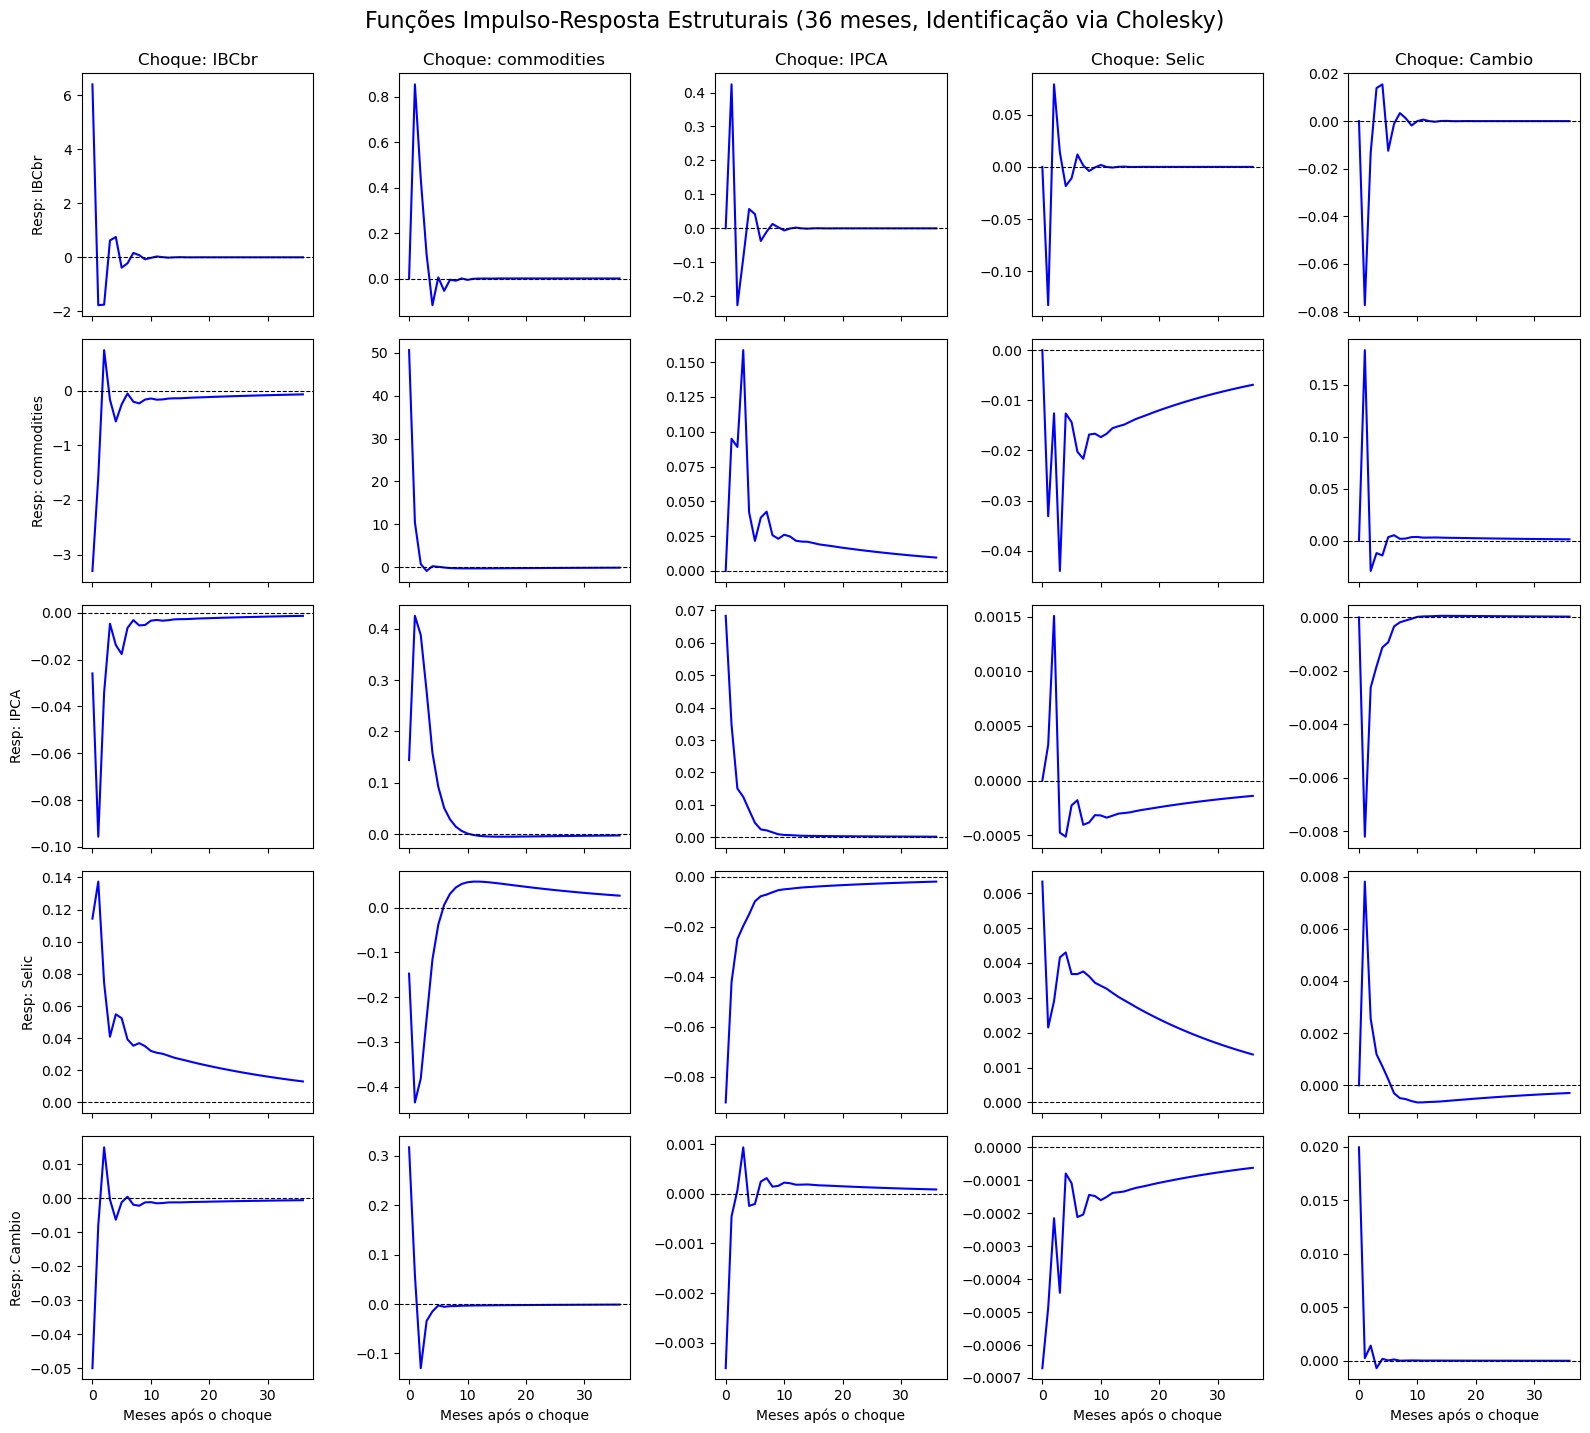

In [41]:
# 2. Estimar o VAR reduzido
model = VAR(df3)
lag_order = 2  # por exemplo
results = model.fit(lag_order)

# 3. Obter a matriz de covariância dos resíduos
u = results.resid
Sigma_u = np.cov(u.T)

# 4. Decomposição de Cholesky
P = cholesky(Sigma_u)

# Verificar a matriz P (matriz de impacto contemporâneo)
print("Matriz de impacto estrutural (Cholesky):\n", P)

# 5. Calcular IRFs estruturais com horizonte de 36 meses
h = 36
irfs_reduced = results.irf(h)
irfs_structural = np.array([irfs_reduced.orth_irfs[i] @ P for i in range(h + 1)])

# 6. Plotar IRFs estruturais
variables = df.columns
fig, axes = plt.subplots(5, 5, figsize=(16, 14), sharex=True)

for i in range(5):  # resposta
    for j in range(5):  # choque
        axes[i, j].plot(range(h + 1), irfs_structural[:, i, j], color='blue')
        axes[i, j].axhline(0, color='black', linewidth=0.8, linestyle='--')
        if i == 0:
            axes[i, j].set_title(f'Choque: {variables[j]}')
        if j == 0:
            axes[i, j].set_ylabel(f'Resp: {variables[i]}')
        if i == 4:
            axes[i, j].set_xlabel('Meses após o choque')

plt.tight_layout()
plt.suptitle("Funções Impulso-Resposta Estruturais (36 meses, Identificação via Cholesky)", fontsize=16, y=1.02)
plt.show()

Matriz de impacto estrutural (Cholesky):
 [[ 2.50464210e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-3.38739222e-01  7.04829154e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-6.82894683e-03  1.93653977e-02  2.58850629e-01  0.00000000e+00
   0.00000000e+00]
 [ 4.01520697e-02 -1.95673312e-02 -2.62497710e-01  7.88094592e-02
   0.00000000e+00]
 [-1.29604289e-02  4.33431885e-02 -1.06231423e-02 -3.00698822e-03
   1.39797826e-01]]


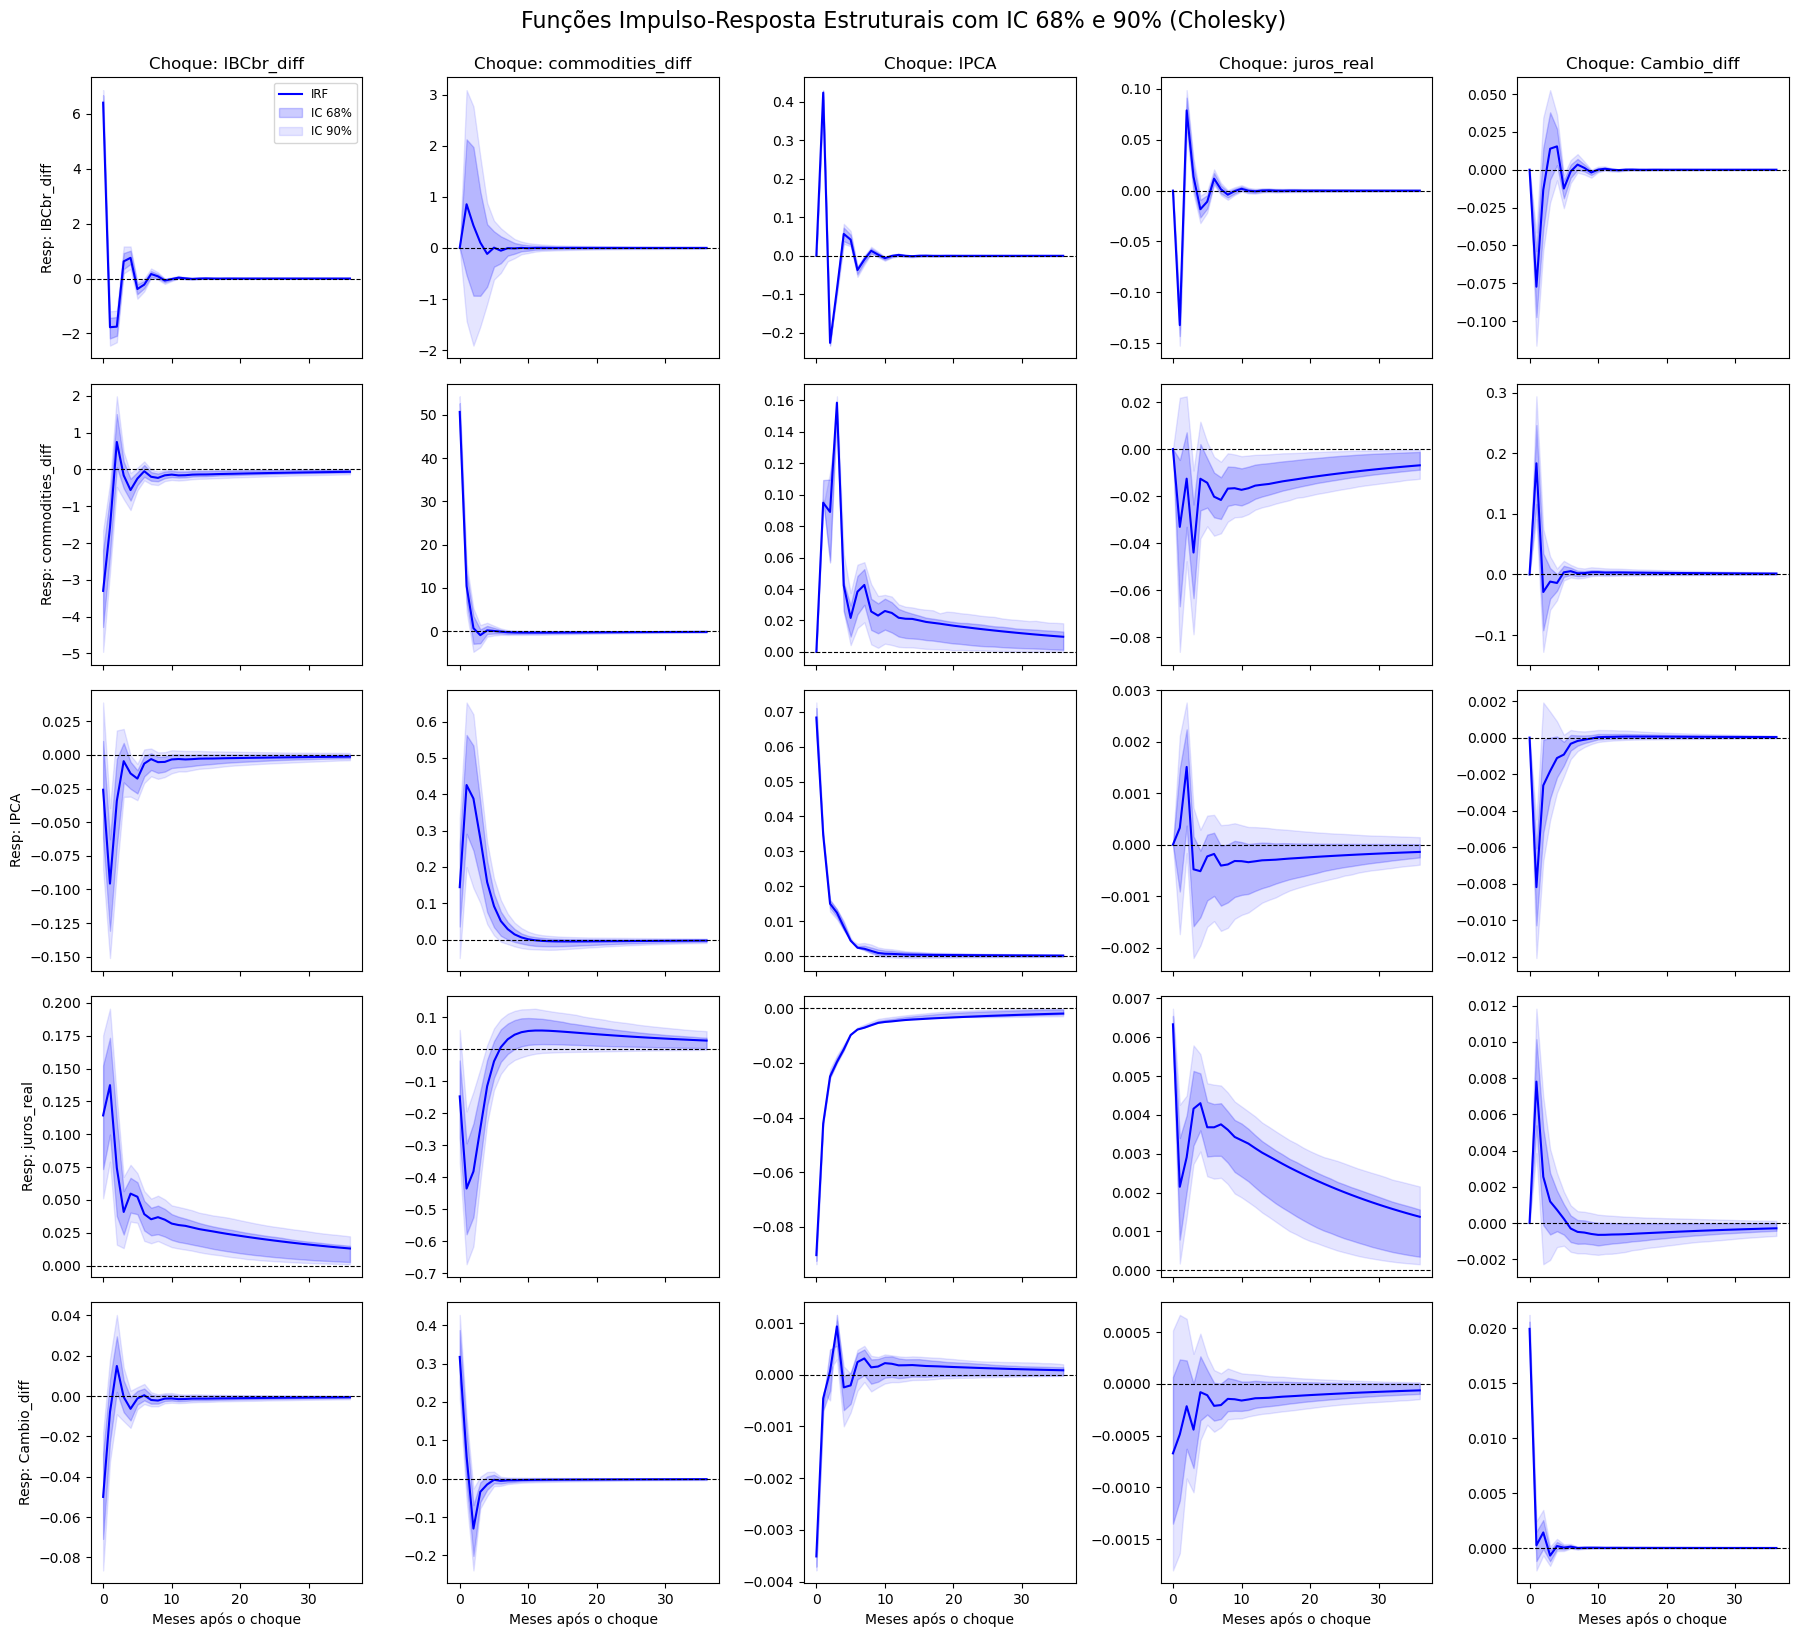

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from numpy.linalg import cholesky

# 1. Estimar o VAR reduzido
model = VAR(df3)
lag_order = 2  # exemplo
results = model.fit(lag_order)

# 2. Obter a matriz de covariância dos resíduos
u = results.resid
Sigma_u = np.cov(u.T)

# 3. Decomposição de Cholesky
P = cholesky(Sigma_u)
print("Matriz de impacto estrutural (Cholesky):\n", P)

# 4. Calcular IRFs com horizonte de 36 meses
h = 36
irfs = results.irf(h)

# IRFs ortogonais (reduzidas)
irf_reduced = irfs.orth_irfs

# 5. Intervalos de confiança via Monte Carlo
ci68_lower, ci68_upper = irfs.errband_mc(repl=1000, signif=0.32, orth=True)
ci90_lower, ci90_upper = irfs.errband_mc(repl=1000, signif=0.10, orth=True)

# 6. Transformar IRFs e ICs para versão estrutural
irf_structural = np.array([irf_reduced[i] @ P for i in range(h + 1)])
ci68_lower_struct = np.array([ci68_lower[i] @ P for i in range(h + 1)])
ci68_upper_struct = np.array([ci68_upper[i] @ P for i in range(h + 1)])
ci90_lower_struct = np.array([ci90_lower[i] @ P for i in range(h + 1)])
ci90_upper_struct = np.array([ci90_upper[i] @ P for i in range(h + 1)])

# 7. Plotar IRFs estruturais com ICs
variables = df3.columns
fig, axes = plt.subplots(5, 5, figsize=(18, 16), sharex=True)

for i in range(5):  # variável resposta
    for j in range(5):  # choque
        axes[i, j].plot(range(h + 1), irf_structural[:, i, j], color='blue', label='IRF')

        # IC 68%
        axes[i, j].fill_between(
            range(h + 1),
            ci68_lower_struct[:, i, j],
            ci68_upper_struct[:, i, j],
            color='blue',
            alpha=0.2,
            label='IC 68%' if i == 0 and j == 0 else ""
        )

        # IC 90%
        axes[i, j].fill_between(
            range(h + 1),
            ci90_lower_struct[:, i, j],
            ci90_upper_struct[:, i, j],
            color='blue',
            alpha=0.1,
            label='IC 90%' if i == 0 and j == 0 else ""
        )

        axes[i, j].axhline(0, color='black', linewidth=0.8, linestyle='--')
        if i == 0:
            axes[i, j].set_title(f'Choque: {variables[j]}')
        if j == 0:
            axes[i, j].set_ylabel(f'Resp: {variables[i]}')
        if i == 4:
            axes[i, j].set_xlabel('Meses após o choque')

# Legenda no primeiro subplot
axes[0, 0].legend(loc='upper right', fontsize='small')
plt.tight_layout()
plt.suptitle("Funções Impulso-Resposta Estruturais com IC 68% e 90% (Cholesky)", fontsize=16, y=1.02)
plt.show()


#### FEVD

Matriz de impacto estrutural (Cholesky):
 [[ 2.50464210e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-3.38739222e-01  7.04829154e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00]
 [-6.82894683e-03  1.93653977e-02  2.58850629e-01  0.00000000e+00
   0.00000000e+00]
 [ 4.01520697e-02 -1.95673312e-02 -2.62497710e-01  7.88094592e-02
   0.00000000e+00]
 [-1.29604289e-02  4.33431885e-02 -1.06231423e-02 -3.00698822e-03
   1.39797826e-01]]


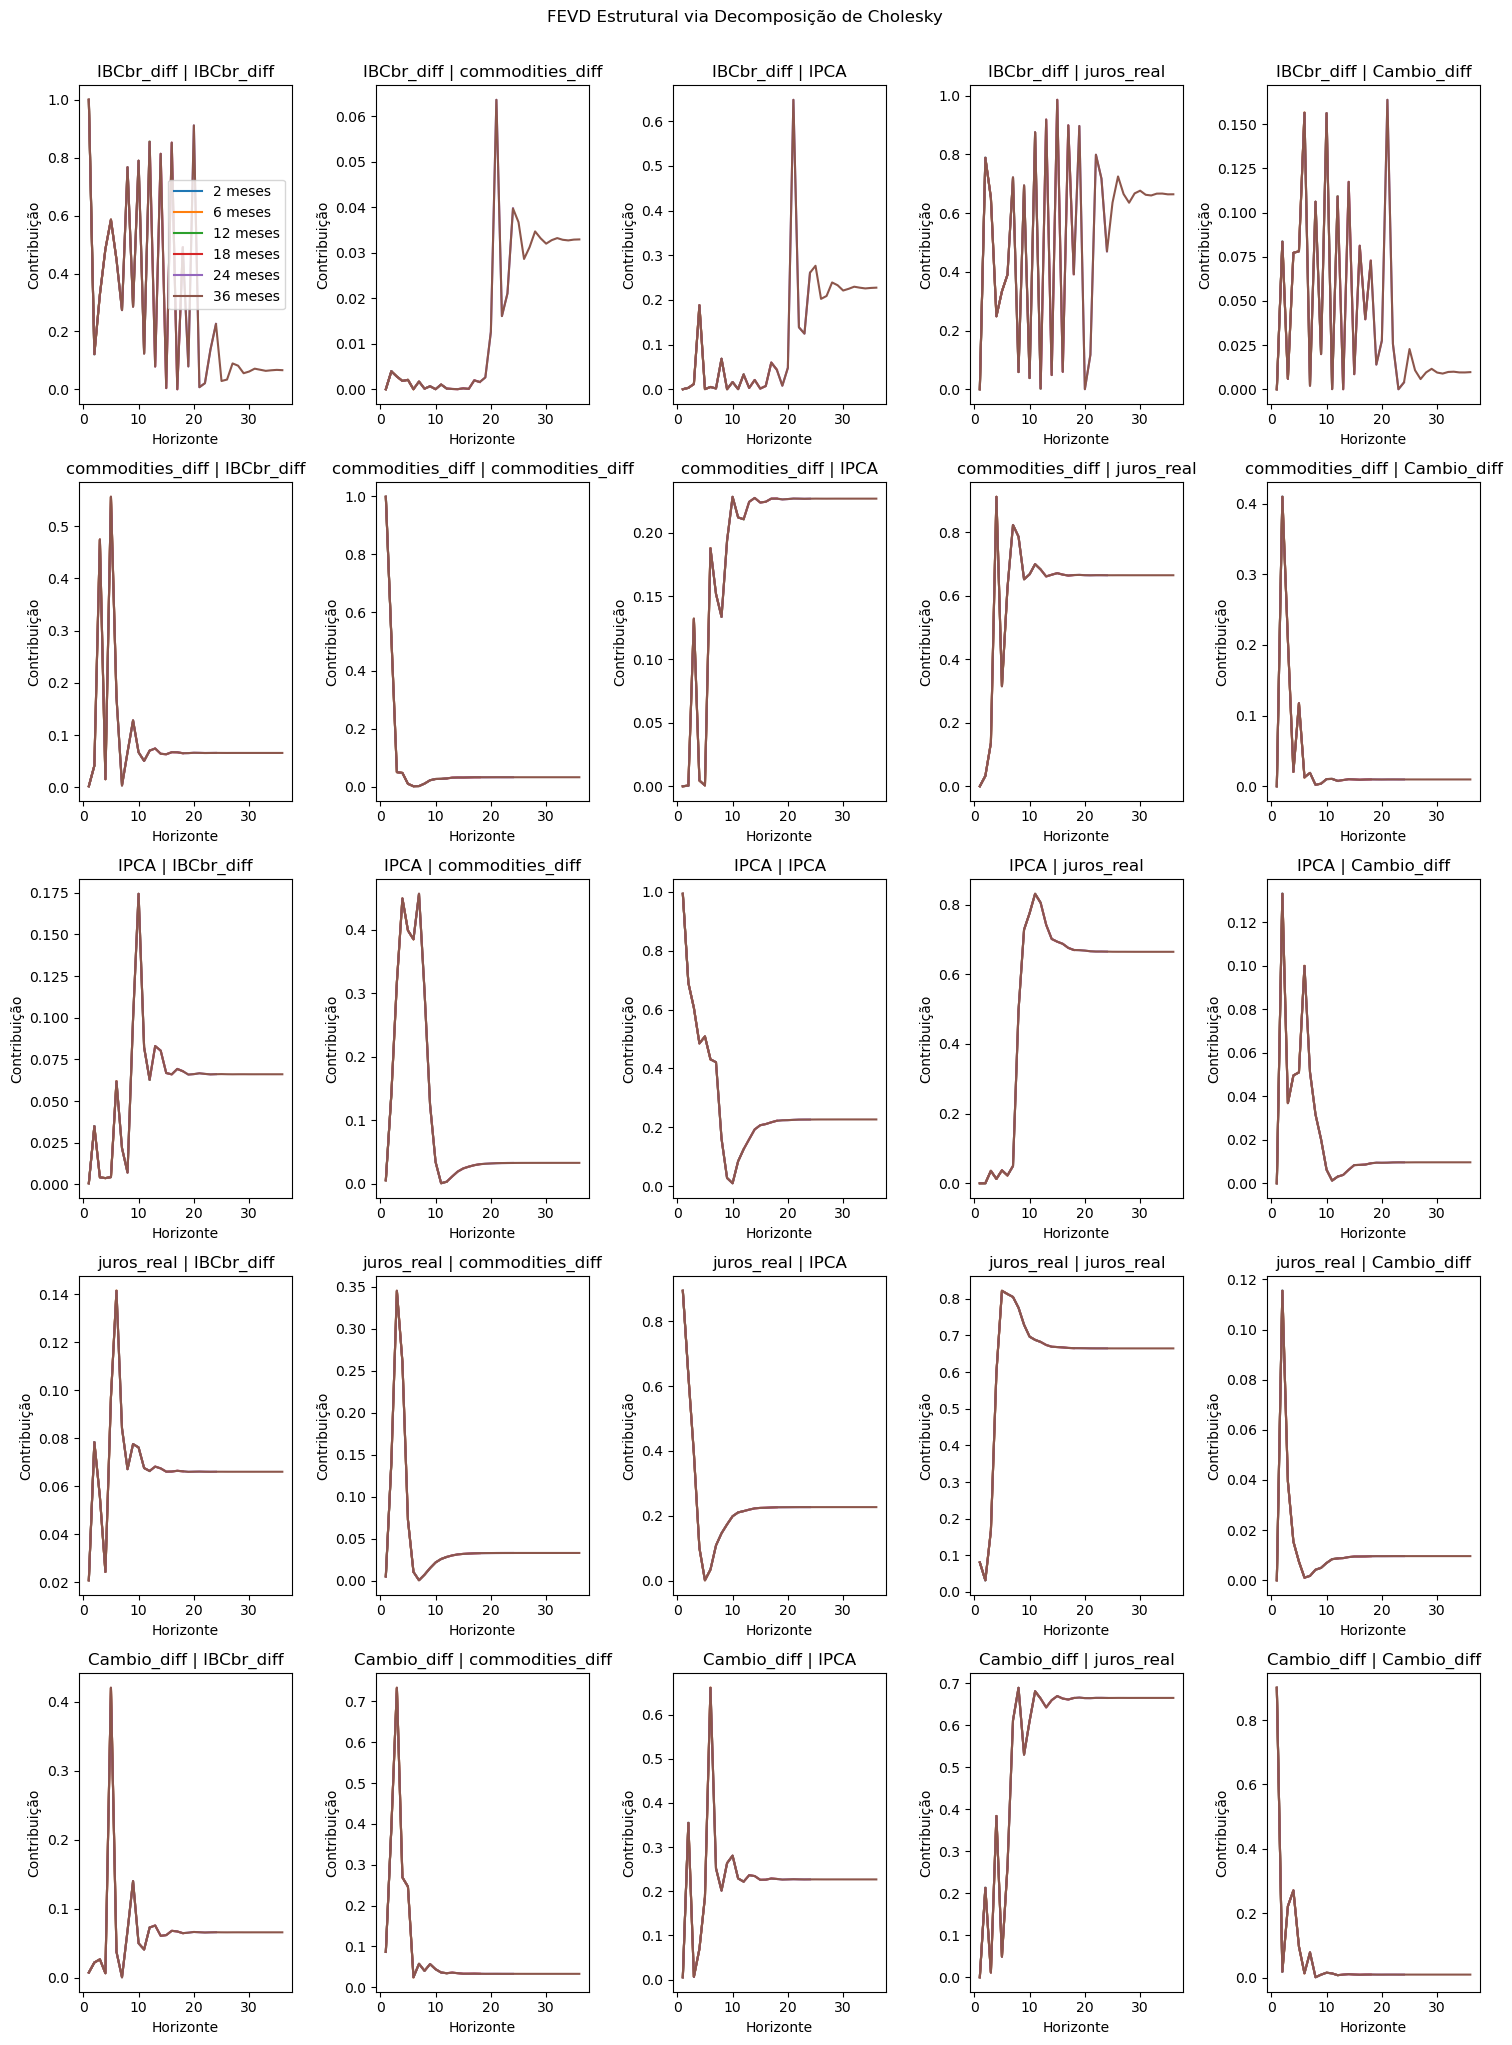

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from numpy.linalg import cholesky

# 1. Estimar o VAR reduzido
model = VAR(df3)
lag_order = 2  # exemplo
results = model.fit(lag_order)

# 2. Obter a matriz de covariância dos resíduos
u = results.resid
Sigma_u = np.cov(u.T)

# 3. Decomposição de Cholesky
P = cholesky(Sigma_u)  # Matriz de impacto estrutural
print("Matriz de impacto estrutural (Cholesky):\n", P)

# 4. Calcular FEVD para os horizontes desejados
horizons = [2, 6, 12, 18, 24, 36]
n_vars = len(df3.columns)
fevd_results = {}

for h in horizons:
    # Obter a representação MA (médias móveis)
    ma_rep = results.ma_rep(h)
    
    # Calcular a FEVD estrutural
    fevd = np.zeros((h, n_vars, n_vars))
    for i in range(h):
        theta = ma_rep[i] @ P
        fevd[i] = (theta ** 2) / np.sum(theta ** 2, axis=1, keepdims=True)
    
    fevd_results[h] = fevd

# 5. Plotar os resultados
variables = df3.columns
n_shocks = n_vars

plt.figure(figsize=(15, 20))
for response_idx, response_var in enumerate(variables):
    for shock_idx, shock_var in enumerate(variables):
        plt.subplot(n_vars, n_vars, response_idx * n_vars + shock_idx + 1)
        
        for h in horizons:
            # Pegar a contribuição acumulada até o horizonte h
            contribution = fevd_results[h][:, response_idx, shock_idx]
            plt.plot(range(1, h+1), contribution, label=f'{h} meses')
        
        plt.title(f'{response_var} | {shock_var}')
        plt.xlabel('Horizonte')
        plt.ylabel('Contribuição')
        if response_idx == 0 and shock_idx == 0:
            plt.legend()

plt.tight_layout()
plt.suptitle("FEVD Estrutural via Decomposição de Cholesky", y=1.02)
plt.show()

In [299]:
irf = results.irf(10)

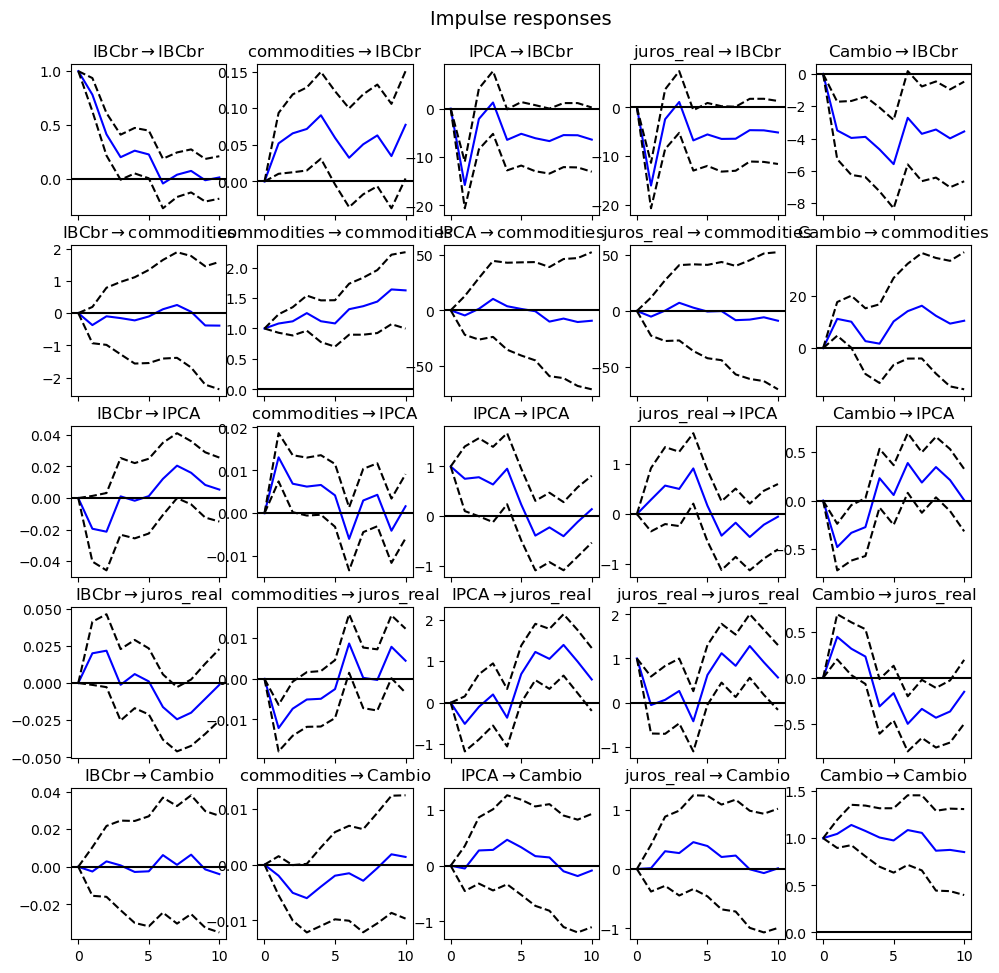

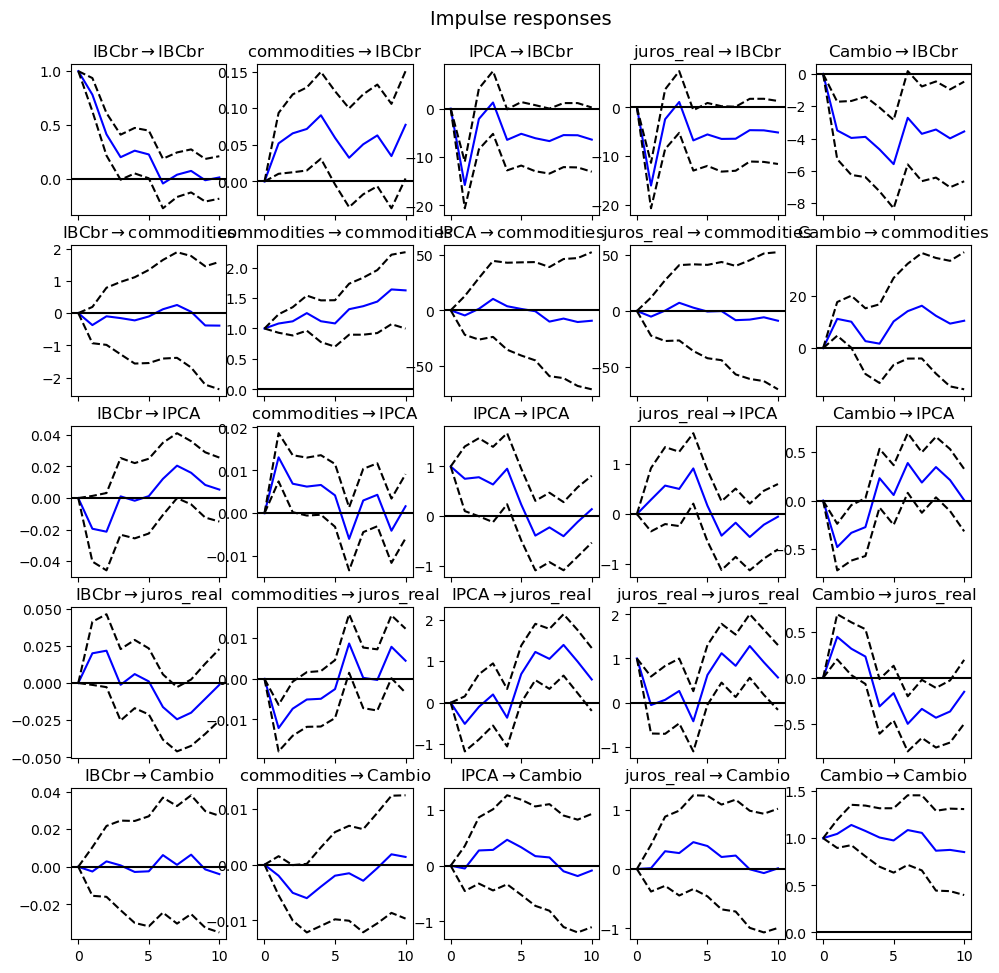

In [301]:
irf.plot(orth=False)

## Teste

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.base.datetools import dates_from_str
from statsmodels.tsa.vector_ar.var_model import SVAR

ImportError: cannot import name 'SVAR' from 'statsmodels.tsa.vector_ar.var_model' (C:\Users\KAWAN\anaconda3\Lib\site-packages\statsmodels\tsa\vector_ar\var_model.py)

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.svar_model import SVAR

# 1. Gerar dados simulados (substitua por seus dados reais)
np.random.seed(12345)
n_obs = 500
dates = pd.date_range('2000-01-01', periods=n_obs, freq='M')
data = np.random.normal(size=(n_obs, 5))

# Adicionar autocorrelação
for i in range(1, n_obs):
    data[i] = 0.9 * data[i-1] + 0.1 * data[i]

# Criar DataFrame
colnames = ['GDP', 'Inflation', 'Interest_Rate', 'Unemployment', 'Exchange_Rate']
df = pd.DataFrame(data, index=dates, columns=colnames)

# 2. Estimar VAR reduzido
model = VAR(df)
lag_order = model.select_order(maxlags=12)
print("Ordem de defasagem selecionada:")
print(lag_order.summary())

# Usar a ordem sugerida pelo critério AIC
var_result = model.fit(maxlags=2)  # Substitua 2 pela ordem selecionada
print("\nResultados do VAR reduzido:")
print(var_result.summary())

# 3. Estimar SVAR com identificação Cholesky
# Definir a matriz de identificação (triangular inferior para Cholesky)
A = np.eye(len(colnames))  # Matriz identidade como ponto de partida

# Criar modelo SVAR
svar_model = SVAR(var_result.endog, var_result.exog, var_result.klags, 
                 svar_type='A', A=A)

# Estimar o modelo
svar_result = svar_model.fit(maxlags=2, maxiter=1000)

print("\nMatriz de impacto contemporâneo (Cholesky):")
print(svar_result.A)

# 4. Análise dos resultados
# Função de resposta ao impulso
irf = svar_result.irf(10)
irf.plot(orth=True)
plt.tight_layout()
plt.show()

# Decomposição da variância do erro de previsão
fevd = svar_result.fevd(10)
print("\nDecomposição da variância do erro de previsão:")
print(fevd.summary())

fevd.plot()
plt.show()

C:\Users\KAWAN\AppData\Local\Temp\ipykernel_10656\1777332709.py:10: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



Ordem de defasagem selecionada:
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -15.14      -15.10   2.654e-07      -15.13
1      -23.02*     -22.76*  1.007e-10*     -22.92*
2       -22.95      -22.47   1.083e-10      -22.76
3       -22.91      -22.22   1.121e-10      -22.64
4       -22.84      -21.94   1.205e-10      -22.49
5       -22.77      -21.65   1.294e-10      -22.33
6       -22.69      -21.36   1.395e-10      -22.17
7       -22.62      -21.08   1.497e-10      -22.02
8       -22.59      -20.83   1.552e-10      -21.90
9       -22.54      -20.57   1.629e-10      -21.76
10      -22.47      -20.28   1.757e-10      -21.61
11      -22.44      -20.04   1.799e-10      -21.50
12      -22.40      -19.78   1.891e-10      -21.37
--------------------------------------------------

Resultados do VAR reduzido:
  Summary of Regression Results   
Model:                         VAR
Me

AttributeError: 'VARResults' object has no attribute 'klags'

Matriz de impacto estrutural (Cholesky):
 [[ 1.00075536  0.          0.          0.          0.        ]
 [-0.04298378  0.88499492  0.          0.          0.        ]
 [-0.05940211 -0.04778714  0.97207941  0.          0.        ]
 [ 0.0436317   0.00531331 -0.02870431  1.01258628  0.        ]
 [-0.00557695  0.08358781 -0.00487847 -0.00197552  0.92009131]]


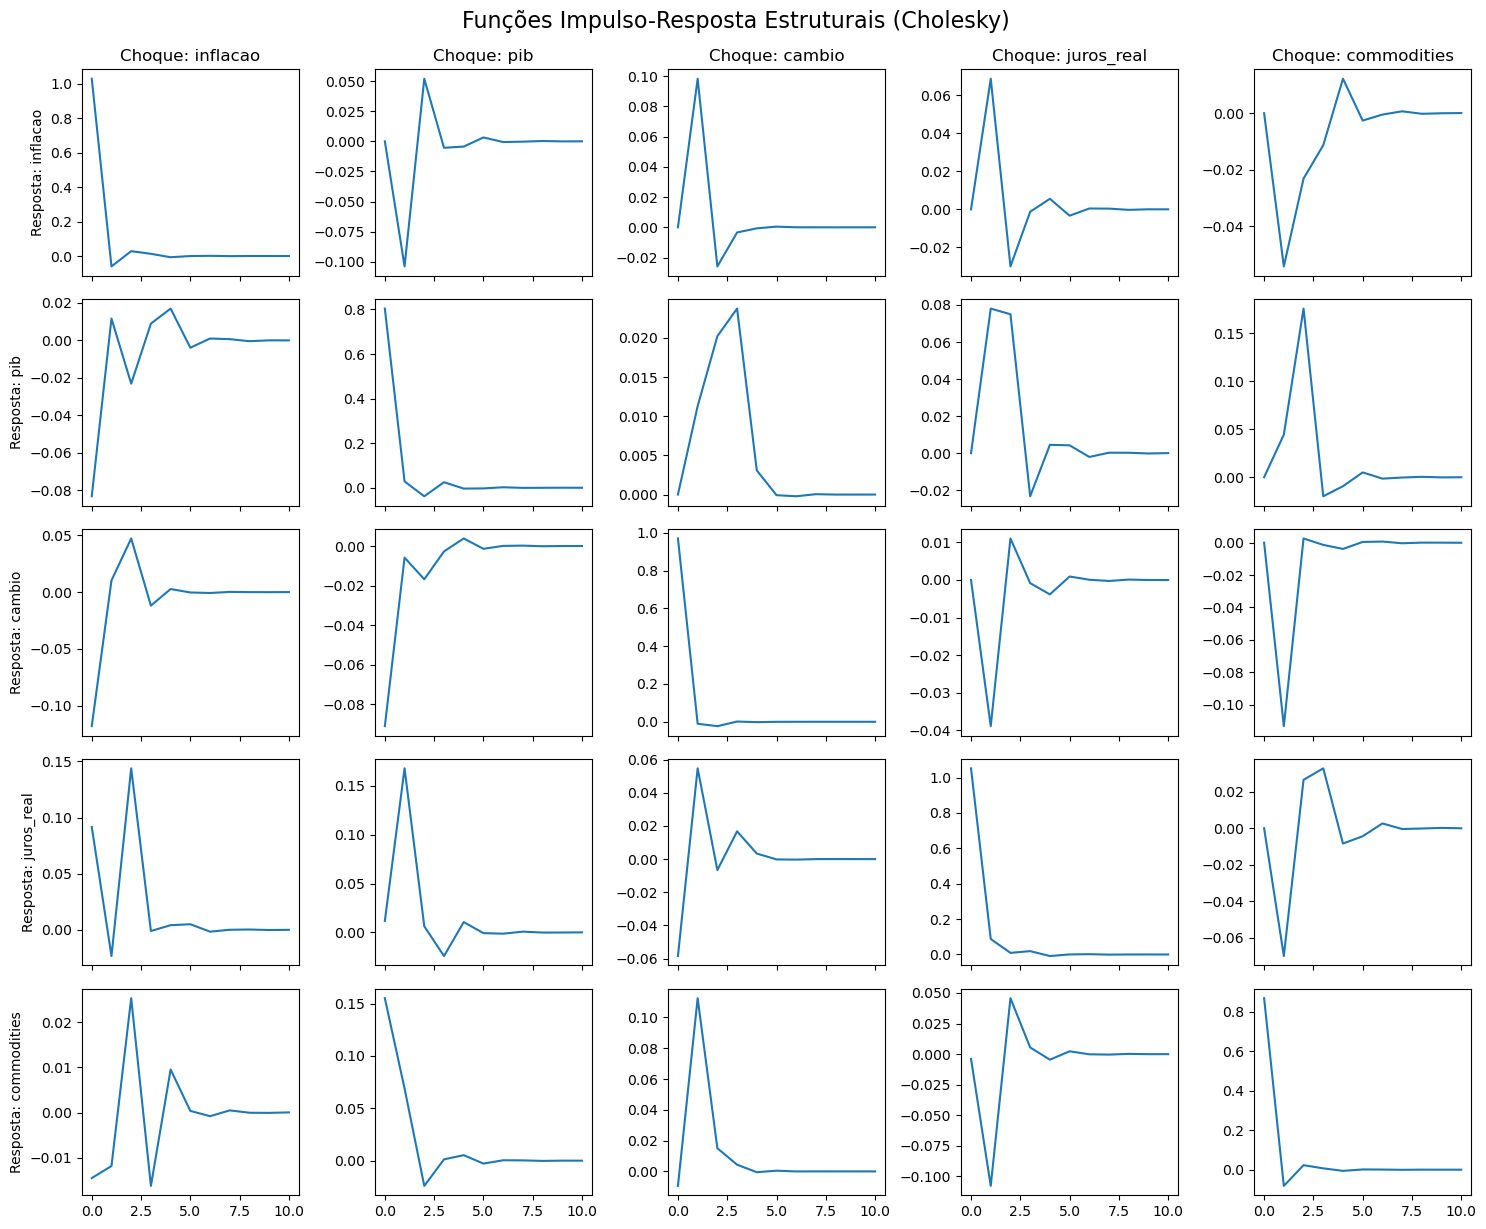

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR
from numpy.linalg import cholesky

# 1. Gerar dados fictícios para 5 variáveis (ex: inflação, PIB, câmbio, juros_real, commodities)
np.random.seed(0)
n_obs = 200
data = np.random.randn(n_obs, 5)

# Colocar os dados em um DataFrame
df = pd.DataFrame(data, columns=['inflacao', 'pib', 'cambio', 'juros_real', 'commodities'])

# 2. Estimar o VAR reduzido
model = VAR(df)
lag_order = 2  # por exemplo
results = model.fit(lag_order)

# 3. Obter a matriz de covariância dos resíduos
u = results.resid
Sigma_u = np.cov(u.T)

# 4. Decomposição de Cholesky
P = cholesky(Sigma_u)

# Verificar a matriz P (matriz de impacto contemporâneo)
print("Matriz de impacto estrutural (Cholesky):\n", P)

# 5. Gerar IRFs estruturais
# Multiplicamos as IRFs do modelo reduzido pela matriz P
irfs_reduced = results.irf(10)  # horizonte = 10
irfs_structural = np.array([irfs_reduced.orth_irfs[i] @ P for i in range(11)])

# 6. Plotar IRFs estruturais
variables = df.columns
horizon = irfs_structural.shape[0]

fig, axes = plt.subplots(5, 5, figsize=(15, 12), sharex=True)
for i in range(5):  # resposta
    for j in range(5):  # choque
        axes[i, j].plot(range(horizon), irfs_structural[:, i, j])
        if i == 0:
            axes[i, j].set_title(f'Choque: {variables[j]}')
        if j == 0:
            axes[i, j].set_ylabel(f'Resposta: {variables[i]}')
plt.tight_layout()
plt.suptitle("Funções Impulso-Resposta Estruturais (Cholesky)", fontsize=16, y=1.02)
plt.show()
